In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:2]

['emma', 'olivia']

In [3]:
len(words)

32033

In [4]:
#Build the vocabulary of characters and mapping to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [5]:
# Building The dataset

block_size = 3 # context length : how many characters we take to predict the next one

X, Y = [], []
for w in words[:1]:
    print(w)
    
    # context = [0]
    # print(context)
    
    context = [0] * block_size
    # print(context)

    # x = w + '.'
    
    # print(x)
    
    for ch in w + '.':
        ix = stoi[ch] # 5
        X.append(context)
        # print(X)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '------>', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)
        

emma
... ------> e
..e ------> m
.em ------> m
emm ------> a
mma ------> .


In [6]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1]])

In [7]:
Y

tensor([ 5, 13, 13,  1,  0])

In [8]:
seed = torch.Generator().manual_seed(123456)

In [9]:
# Embedding Table / Glorified Lookup table
C = torch.randn((27,2), generator=seed)
C

tensor([[-1.1218, -1.8445],
        [ 1.0258,  2.1921],
        [-1.4322,  1.5293],
        [ 1.2118,  0.0423],
        [ 0.3807,  0.0538],
        [ 0.5047, -0.4987],
        [-0.4891,  0.0578],
        [ 0.9436,  0.9775],
        [ 0.7843, -0.1034],
        [ 0.1187, -0.2737],
        [ 1.1537,  1.3910],
        [ 1.0732, -1.2210],
        [ 0.9103,  0.8257],
        [ 0.1247,  0.8079],
        [ 0.1415, -0.5531],
        [ 1.0828, -1.7865],
        [-0.7372, -0.7429],
        [-0.4891,  2.4613],
        [-0.7179, -0.2446],
        [-0.8818,  1.6565],
        [-0.5419, -2.4956],
        [ 0.3731,  1.2806],
        [-0.1539,  0.2954],
        [-1.5935, -0.0451],
        [-0.2014, -0.7450],
        [-0.2250,  0.0894],
        [-1.0029, -1.1601]])

In [10]:
C[5]

tensor([ 0.5047, -0.4987])

In [11]:
emb = C[X]
emb.shape

torch.Size([5, 3, 2])

In [12]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)

In [13]:
emb

tensor([[[-1.1218, -1.8445],
         [-1.1218, -1.8445],
         [-1.1218, -1.8445]],

        [[-1.1218, -1.8445],
         [-1.1218, -1.8445],
         [ 0.5047, -0.4987]],

        [[-1.1218, -1.8445],
         [ 0.5047, -0.4987],
         [ 0.1247,  0.8079]],

        [[ 0.5047, -0.4987],
         [ 0.1247,  0.8079],
         [ 0.1247,  0.8079]],

        [[ 0.1247,  0.8079],
         [ 0.1247,  0.8079],
         [ 1.0258,  2.1921]]])

In [14]:
emb[:,0,:],emb[:,1,:],emb[:,2,:]

(tensor([[-1.1218, -1.8445],
         [-1.1218, -1.8445],
         [-1.1218, -1.8445],
         [ 0.5047, -0.4987],
         [ 0.1247,  0.8079]]),
 tensor([[-1.1218, -1.8445],
         [-1.1218, -1.8445],
         [ 0.5047, -0.4987],
         [ 0.1247,  0.8079],
         [ 0.1247,  0.8079]]),
 tensor([[-1.1218, -1.8445],
         [ 0.5047, -0.4987],
         [ 0.1247,  0.8079],
         [ 0.1247,  0.8079],
         [ 1.0258,  2.1921]]))

In [15]:
torch.concat(torch.unbind(emb,1),1)

tensor([[-1.1218, -1.8445, -1.1218, -1.8445, -1.1218, -1.8445],
        [-1.1218, -1.8445, -1.1218, -1.8445,  0.5047, -0.4987],
        [-1.1218, -1.8445,  0.5047, -0.4987,  0.1247,  0.8079],
        [ 0.5047, -0.4987,  0.1247,  0.8079,  0.1247,  0.8079],
        [ 0.1247,  0.8079,  0.1247,  0.8079,  1.0258,  2.1921]])

In [16]:
a = torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [17]:
a.shape

torch.Size([18])

In [18]:
a.view(3,3,2)

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

In [19]:
a.storage()

/tmp/ipykernel_10593/214256462.py:1: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  a.storage()


 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

In [20]:
emb.storage()

 -1.1218369007110596
 -1.8445433378219604
 -1.1218369007110596
 -1.8445433378219604
 -1.1218369007110596
 -1.8445433378219604
 -1.1218369007110596
 -1.8445433378219604
 -1.1218369007110596
 -1.8445433378219604
 0.504667341709137
 -0.49874359369277954
 -1.1218369007110596
 -1.8445433378219604
 0.504667341709137
 -0.49874359369277954
 0.12470921874046326
 0.8078563213348389
 0.504667341709137
 -0.49874359369277954
 0.12470921874046326
 0.8078563213348389
 0.12470921874046326
 0.8078563213348389
 0.12470921874046326
 0.8078563213348389
 0.12470921874046326
 0.8078563213348389
 1.02579927444458
 2.192124843597412
[torch.storage.TypedStorage(dtype=torch.float32, device=cpu) of size 30]

In [21]:
emb.view(5,6)

tensor([[-1.1218, -1.8445, -1.1218, -1.8445, -1.1218, -1.8445],
        [-1.1218, -1.8445, -1.1218, -1.8445,  0.5047, -0.4987],
        [-1.1218, -1.8445,  0.5047, -0.4987,  0.1247,  0.8079],
        [ 0.5047, -0.4987,  0.1247,  0.8079,  0.1247,  0.8079],
        [ 0.1247,  0.8079,  0.1247,  0.8079,  1.0258,  2.1921]])

In [22]:
h = emb.view(-1,6) @ W1 + b1

In [23]:
h

tensor([[ 3.6146e-02,  1.8693e+00,  6.7483e+00, -1.0198e+00,  1.0843e+00,
          2.2033e+00,  4.4431e+00, -3.0133e-02, -9.4471e-01, -3.4105e+00,
          4.2007e+00,  5.8549e-01,  1.4334e+00,  1.7521e+00, -5.6863e+00,
         -3.8648e-01, -6.5569e+00,  6.6492e+00,  6.9098e+00, -2.4218e+00,
          3.2618e+00,  5.9516e-01, -2.0780e+00, -7.5916e-01, -6.7088e-01,
          2.8618e+00,  3.0677e+00,  3.1956e-01,  3.7010e+00, -3.4135e+00,
          9.8585e-01, -6.6721e+00, -1.8035e+00, -5.7968e-01,  6.3091e+00,
          3.9234e+00, -5.1565e+00, -2.6708e+00,  1.5272e+00, -1.8806e+00,
          8.2946e-01,  3.7973e+00, -4.0867e+00,  3.7197e+00,  8.1723e+00,
          4.7676e+00,  1.1440e+00, -1.5068e+00,  4.1688e-01, -2.9087e+00,
         -3.5909e+00,  4.9061e-01, -4.4365e+00,  5.5928e+00, -1.2086e+00,
         -1.0766e+00, -5.4199e+00,  5.6820e-01, -3.9942e+00, -4.2542e-01,
          1.6966e+00, -3.3444e+00, -4.0296e+00, -3.2371e+00, -8.8920e-01,
         -1.0380e+01,  4.1057e+00, -1.

In [24]:
h = torch.tanh(h)

In [25]:
h.shape

torch.Size([5, 100])

In [26]:
W2 = torch.randn((100,27), generator=seed)
b2 = torch.randn(27, generator=seed)

In [27]:
logits = h @ W2 + b2
logits

tensor([[  7.1929,  -4.9414,   6.2460,  -6.9480,   1.7259, -22.3181,  10.8195,
          -5.4410,  -5.4483,  -5.7155,   5.8636,  -9.3290,  -5.6096,  -5.3087,
           5.5662,  -3.0430,  -1.1712,  17.5563,  14.2050, -15.4816, -21.2023,
           7.0156,   4.2740,   0.8039,   1.2708,   2.8651,  -8.8723],
        [ 12.1471,  -4.2851,  -4.9008,  -9.0814,   1.9384, -12.3587,  13.4617,
         -14.5200,  -4.2936, -21.0323,   9.9012, -18.4965, -14.0919,  -3.5111,
          15.4702,   1.6704,   7.8072,   6.7833,  10.1344,  -9.6413,  -8.5809,
           1.8481,  15.4176,   5.5098,   0.2844, -13.7213,  -3.7177],
        [  9.1947,   6.1382,   0.4615, -10.5194,  -1.5320,  11.9911,   7.6156,
         -16.2768,  -9.1888, -18.0854,  -2.1623, -12.1565, -12.6403,  -8.5570,
          12.1555,   3.0294,   6.2579,   2.9754,   6.6074,  -5.8820,  -1.5213,
           1.2034,   2.4312, -12.0251,   5.0177, -10.6387,  -0.5899],
        [ 11.3818,   6.0687,   0.6204, -11.6225,  -6.8092,  10.7403, -11.1962,


In [28]:
logits.shape

torch.Size([5, 27])

In [29]:
counts = logits.exp()

In [30]:
probs = counts / counts.sum(1, keepdims=True)
probs

tensor([[3.0462e-05, 1.6364e-10, 1.1817e-05, 2.2000e-11, 1.2867e-07, 4.6483e-18,
         1.1449e-03, 9.9291e-11, 9.8570e-11, 7.5458e-11, 8.0617e-06, 2.0340e-12,
         8.3884e-11, 1.1334e-10, 5.9882e-06, 1.0924e-09, 7.1004e-09, 9.6496e-01,
         3.3811e-02, 4.3284e-15, 1.4186e-17, 2.5513e-05, 1.6446e-06, 5.1174e-08,
         8.1626e-08, 4.0197e-07, 3.2118e-12],
        [1.6933e-02, 1.2369e-09, 6.6829e-10, 1.0218e-11, 6.2400e-07, 3.8551e-13,
         6.3050e-02, 4.4401e-14, 1.2264e-09, 6.5937e-17, 1.7922e-03, 8.3256e-16,
         6.8122e-14, 2.6821e-09, 4.6985e-01, 4.7730e-07, 2.2078e-04, 7.9304e-05,
         2.2629e-03, 5.8367e-12, 1.6854e-11, 5.7011e-07, 4.4579e-01, 2.2193e-05,
         1.1936e-07, 9.8681e-14, 2.1815e-09],
        [2.6953e-02, 1.2682e-03, 4.3436e-06, 7.3939e-11, 5.9166e-07, 4.4163e-01,
         5.5570e-03, 2.3360e-13, 2.7973e-10, 3.8282e-14, 3.1503e-07, 1.4385e-11,
         8.8674e-12, 5.2618e-10, 5.2057e-01, 5.6633e-05, 1.4295e-03, 5.3656e-05,
         2.0275e-

In [31]:
probs.shape

torch.Size([5, 27])

In [32]:
probs[0].sum()

tensor(1.)

In [33]:
loss = -probs[torch.arange(5),Y].log().mean()
loss

tensor(22.3895)

In [34]:
# Model

In [35]:
X.shape, Y.shape

(torch.Size([5, 3]), torch.Size([5]))

In [36]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2),generator=g, requires_grad=True)
W1 = torch.randn((6,100), generator=g, requires_grad=True)
b1 = torch.randn(100, generator=g, requires_grad=True)
W2 = torch.randn((100,27), generator=g, requires_grad=True)
b2 = torch.randn(27,generator=g, requires_grad=True)
parameters = [C, W1, b1, W2, b2]

In [37]:
sum(p.nelement() for p in parameters)

3481

In [38]:
learning_rate = -0.1

In [39]:
for _ in range(10):
    # Forward Pass
    xemb = C[X] # 5,3,2
    # --- Neuron ----
    h = xemb.view(-1,6) @ W1 + b1
    h = torch.tanh(h)
    
    # --- Loss Calc ----
    logits = h @ W2 + b2
    # counts = logits.exp()
    # probs = counts / counts.sum(1, keepdims=True)
    # loss = -probs[torch.arange(5),Y].log().mean()
    loss = F.cross_entropy(logits,Y)
    print(loss.item())
    
    # Back Prop
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # Update
    for p in parameters:
        p.data += -0.01 * p.grad

24.941761016845703
23.113460540771484
21.680532455444336
20.46097183227539
19.3480281829834
18.304737091064453
17.318593978881836
16.388042449951172
15.514554977416992
14.695947647094727


In [40]:
logits.max(1)

torch.return_types.max(
values=tensor([15.3890, 17.2643, 20.9619, 16.6225, 12.2919], grad_fn=<MaxBackward0>),
indices=tensor([ 9, 10,  9, 14,  2]))

# MLP Explained

In [41]:
# === Building a dataset ===
xs = []
ys = []

block_size = 3
content = [0] * 3

for w in words[:1]: 
    for ch in w + '.':
        ix = stoi[ch]
        xs.append(content)
        ys.append(ix)
        content = content[1:] + [ix]

xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [42]:
xs,ys

(tensor([[ 0,  0,  0],
         [ 0,  0,  5],
         [ 0,  5, 13],
         [ 5, 13, 13],
         [13, 13,  1]]),
 tensor([ 5, 13, 13,  1,  0]))

In [43]:
seedz = torch.Generator().manual_seed(2147483647) # For making it deterministic

In [44]:
# === LAYER BUILDING ===
Cz = torch.randn((27,2),generator=seedz, requires_grad=True) # embedding Matrix

In [45]:
# ==== Embedding + Foward Pass ===
xs_embedded = Cz[xs]

In [46]:
# === 1st layer ===
# XS contains a shape of [...,3(context window),2(embedding vectors)]
W1 = torch.randn((6,100), generator=seedz, requires_grad=True) # weights matrix
b1 = torch.randn((100), generator=seedz, requires_grad=True) # bias matrix

In [47]:
# === Defining Neurons in 1st Layer + Forward Pass ===
h = xs_embedded.view(-1,6) @ W1 + b1
h = torch.tanh(h)

In [48]:
# === 2nd Layer ===

W2 = torch.randn((100,27), generator=seedz, requires_grad=True)
b2 = torch.randn((27), generator=seedz, requires_grad=True)

In [49]:
parameters = [Cz, W1, b1, W2, b2]

In [50]:
# === Defining Neurons in 2nd Layer + Forward Pass ===
logits = h @ W2 + b2

In [51]:
# === Loss Calculation
loss = F.cross_entropy(logits, ys)
print(loss.item())

24.941761016845703


In [52]:
# === Backpropagation ===
for p in parameters:
    p.grad = None
    
loss.backward()

In [53]:
# === Updating Data
for p in parameters:
    p.data += -0.1 * p.grad

# GPU Bigram MLP

In [54]:
device = "cuda" if torch.cuda.is_available else "cpu"
device

'cuda'

In [55]:
def build_dataset(words):
    block_size = 3
    gx = []
    gy = []
    
    for w in words:
        content = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            gx.append(content)
            gy.append(ix)
            content = content[1:] + [ix]

    gx = torch.tensor(gx).to(device)
    gy = torch.tensor(gy).to(device)
    print(gx.shape,gy.shape)
    return gx,gy

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev= build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [56]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [57]:
gg = torch.Generator(device=device).manual_seed(2147483647)

In [58]:
gC = torch.randn((27,17), generator=g).to(device)
gW1 = torch.randn((51,579), generator=g).to(device)
gb1 = torch.randn((579), generator=g).to(device)
gW2 = torch.randn((579,27), generator=g).to(device)
gb2 = torch.randn((27), generator=g).to(device)
parameters = [gC, gW1, gb1, gW2, gb2]

In [59]:
sum(p.nelement() for p in parameters)

46227

In [60]:
for p in parameters:
    p.requires_grad = True

In [61]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre

In [62]:
lri = []
lossi = []
stepi = []

In [63]:
for i in range(100000):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (43,))
    
    # Forward Pass
    gx_emb = gC[Xtr[ix]]
    h = torch.tanh(gx_emb.view(-1,51) @ gW1 + gb1)
    logits = h @ gW2 + gb2
    loss = F.cross_entropy(logits,Ytr[ix])
    #print(loss.item())
    
    # Back Propagation
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update
    lr = 0.001 if i < 50000 else 0.0001
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    # lri.append(lrs[i])
    stepi.append(i)
    lossi.append(loss.log10().item())
#print(loss.item())

In [64]:
print(loss.item())

6.783553600311279


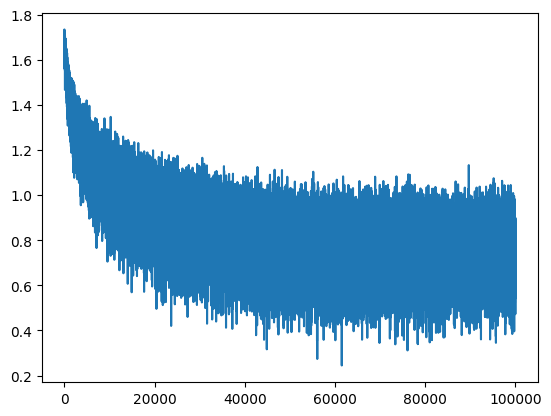

In [65]:
plt.plot(stepi,lossi)

In [66]:
gx_emb = gC[Xtr]
h = torch.tanh(gx_emb.view(-1,51) @ gW1 + gb1)
logits = h @ gW2 + gb2
loss = F.cross_entropy(logits,Ytr)
print(loss.item())

5.7918171882629395


In [67]:
gx_emb = gC[Xdev]
h = torch.tanh(gx_emb.view(-1,51) @ gW1 + gb1)
logits = h @ gW2 + gb2
loss = F.cross_entropy(logits,Ydev)
print(loss.item())

6.012211799621582


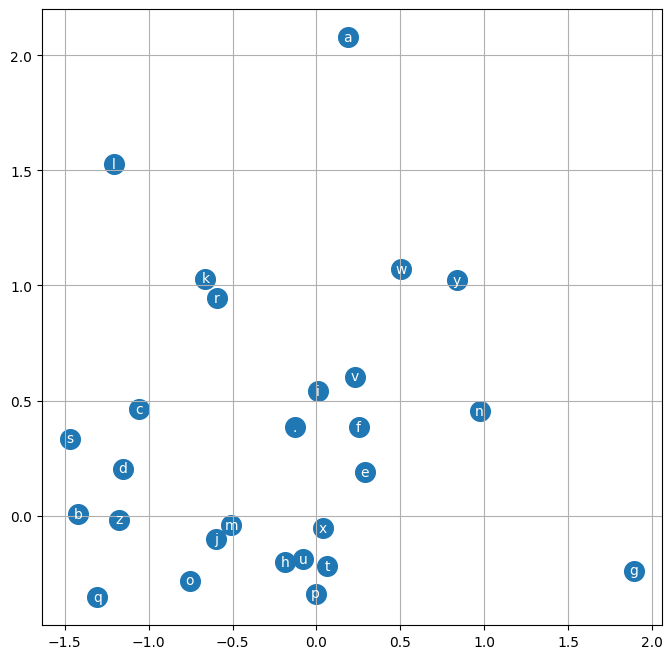

In [68]:
plt.figure(figsize=(8,8))
plt.scatter(gC[:,0].to(device='cpu').data,gC[:,1].to(device='cpu').data, s=200)
for i in range(gC.shape[0]):
    plt.text(gC[i,0].to(device='cpu').item(),gC[i,1].to(device='cpu').item(),itos[i],ha="center",va="center",color="white")
plt.grid('minor')

In [69]:
# training split, dev/validation split, test split.
# 80% , 10%, 10%

# Sampling

In [70]:
for _ in range(20):

    out = []
    context = [0] * block_size

    while True:
        gemb = gC[torch.tensor([context])]
        h = torch.tanh(gemb.view(1,-1) @ gW1 + gb1)
        logits = h @ gW2 + gb2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1,generator=gg).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix ==0:
            break

    print(''.join(itos[i] for i in out))

kuya.
eshani.
moig.
beo.
brah.
gulyten.
sha.
xolarafaine.
delan.
zalier.
gelysin.
any.
aleeuo.
khyasll.
jer.
somillee.
thianne.
sand.
jamelia.
avaruonag.
